In [17]:
# Setup: load config and prepare datasets using the library helpers
from pathlib import Path

import pandas as pd
import xarray as xr
from IPython.display import Image, display

from swissclim_evaluations.cli import _load_yaml, prepare_datasets, run_selected
from swissclim_evaluations.metrics.probabilistic import (
    run_probabilistic_wbx,
)

# Locate configuration relative to the notebook location
cfg_path = None
for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    candidate = base / "config" / "example_config.yaml"
    if candidate.is_file():
        cfg_path = candidate
        break
if cfg_path is None:
    raise FileNotFoundError(
        "Could not find config/example_config.yaml in cwd, parent, or grandparent directories."
    )

# Load configuration and derive output root relative to project root (parent of notebooks)
cfg = _load_yaml(cfg_path)
project_root = Path.cwd().parent
cfg_output = cfg.get("paths", {}).get("output_root", "output/notebook_prob_wbx")
out_root = (
    (project_root / cfg_output).resolve()
    if not cfg_output.startswith("/")
    else Path(cfg_output)
)
out_root.mkdir(parents=True, exist_ok=True)
print(f"Output root: {out_root}")

# Prepare datasets once
(
    ds_targets,
    ds_predictions,
    ds_targets_std,
    ds_predictions_std,
) = prepare_datasets(cfg)

Output root: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm


/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/src/swissclim_evaluations/cli.py:550: RuntimeWarning: Rechunking ground_truth to policy {'init_time': 1, 'lead_time': 1, 'level': 1, 'ensemble': -1, 'latitude': -1, 'longitude': -1}. This may increase memory usage and runtime.
  ds_target = data_mod.enforce_chunking(ds_target, dataset_name="ground_truth")
/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/src/swissclim_evaluations/cli.py:551: RuntimeWarning: Rechunking ml to policy {'init_time': 1, 'lead_time': 1, 'level': 1, 'ensemble': -1, 'latitude': -1, 'longitude': -1}. This may increase memory usage and runtime.
  ds_prediction = data_mod.enforce_chunking(ds_prediction, dataset_name="ml")


In [18]:
# Toggle to run the full pipeline via CLI orchestration
RUN_ALL = False

In [19]:
# If RUN_ALL is enabled, execute the orchestrator using the same config
# and skip the per-chapter call below to avoid duplication.
if RUN_ALL:
    run_selected(cfg)

In [20]:
# Show the prepared datasets (quick peek)
ds_targets

<xarray.Dataset> Size: 448MB
Dimensions:                  (init_time: 27, lead_time: 1, latitude: 720,
                              longitude: 1440, level: 3)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * level                    (level) int64 24B 100 500 1000
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 112MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
    u_component_of_wind      (level, latitude, longitude, init_time, lead_time) float32 336MB dask.array<chunksize=(1, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

In [21]:
# Show predictions (quick peek)
ds_predictions

<xarray.Dataset> Size: 896MB
Dimensions:                  (init_time: 27, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 896MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    model_ckpt-step=7300-loss_train=0.07.ckpt

In [22]:
ds_targets

<xarray.Dataset> Size: 448MB
Dimensions:                  (init_time: 27, lead_time: 1, latitude: 720,
                              longitude: 1440, level: 3)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * level                    (level) int64 24B 100 500 1000
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 112MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
    u_component_of_wind      (level, latitude, longitude, init_time, lead_time) float32 336MB dask.array<chunksize=(1, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

In [23]:
ds_predictions

<xarray.Dataset> Size: 896MB
Dimensions:                  (init_time: 27, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 896MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    model_ckpt-step=7300-loss_train=0.07.ckpt

In [24]:
# Compute standardized WBX outputs (CSVs, NetCDFs, optional CRPS map) via library function
if not RUN_ALL:
    run_probabilistic_wbx(
        ds_target=ds_targets,
        ds_prediction=ds_predictions,
        out_root=out_root,
        plotting_cfg=cfg.get("plotting", {}),
        all_cfg=cfg,
    )

[probabilistic] saved /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/spread_skill_ratio_init2023010200-2023010812_lead006h-006h_ensprob.csv
[probabilistic] saved /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_ensemble_init2023010200-2023010812_lead006h-006h_ensprob.csv
Wrote: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/prob_metrics_temporal_init2023010200-2023010812_lead006h-006h_ensprob.nc
Wrote: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/prob_metrics_spatial_init2023010200-2023010812_lead006h-006h_ensprob.nc
[probabilistic] saved /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_map_wbx_10m_u_component_of_wind_init2023010200-2023010812_lead006h-006h_ensprob.png


In [30]:
# Read temporal results from disk by searching typical filenames in likely module directories
from pathlib import Path

module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
patterns = [
    "prob_metrics_temporal_*.nc",         # WBX-style detailed name
]

candidates: list[Path] = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            candidates.extend(md.glob(pat))

if candidates:
    # Pick the most recent file by modification time
    temporal_fn = max(candidates, key=lambda p: p.stat().st_mtime)
    ds_temporal = xr.load_dataset(temporal_fn, engine="scipy")
    print("Loaded:", temporal_fn)
    # Show a quick summary: dims, variables, and first few values for one variable
    print("dims:", ds_temporal.dims)
    print("data_vars:", list(ds_temporal.data_vars)[:6], "...")
    # If CRPS exists, show a small table grouped over time
    crps_vars = [v for v in ds_temporal.data_vars if v.startswith("CRPS.")]
    if crps_vars:
        try:
            preview = ds_temporal[crps_vars[0]].mean([
                d for d in ["init_time", "lead_time"] if d in ds_temporal.dims
            ])
            display(preview.to_dataframe().head(10))
        except Exception:
            pass
else:
    print(
        "Temporal file not found under:",
        ", ".join(str(md) for md in module_dirs if md.exists()) or "(no module directories found)",
    )

Loaded: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/prob_metrics_temporal_init2023010200-2023010812_lead006h-006h_ensprob.nc
dims: FrozenMappingWarningOnValuesAccess({'init_time': 27, 'lead_time': 1, 'region': 12})
data_vars: ['CRPS.10m_u_component_of_wind', 'SSR.10m_u_component_of_wind'] ...


,CRPS.10m_u_component_of_wind
region,
global,0.194013
tropics,0.185832
northern-hemisphere,0.210408
southern-hemisphere,0.185938
europe,0.217394
north-america,0.211488
north-atlantic,0.236422
north-pacific,0.293078
east-asia,0.207862


In [32]:
# List generated outputs for this module (no recomputation)
from pathlib import Path

module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
found_any = False
for section in module_dirs:
    if section.exists():
        print(f"Listing outputs under: {section}")
        for p in sorted(section.glob("**/*")):
            print(p)
        found_any = True

if not found_any:
    print(
        "No outputs yet under:",
        ", ".join(str(md) for md in module_dirs),
        "Run the cells above.",
    )

Listing outputs under: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic
/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_ensemble_init2023010200-2023010812_lead006h-006h_ensprob.csv
/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_map_wbx_10m_u_component_of_wind_init2023010200-2023010812_lead006h-006h_ensprob.png
/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/prob_metrics_spatial_init2023010200-2023010812_lead006h-006h_ensprob.nc
/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/prob_metrics_temporal_init2023010200-2023010812_lead006h-006h_ensprob.nc
/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/spread_skill_ratio_init2023010200-2023010812_lead006h-006h_enspro

In [35]:
# Read spatial results from disk with robust discovery across module dirs and patterns
from pathlib import Path

module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
patterns = [
    "prob_metrics_spatial_*.nc",        # WBX-style detailed name
]

candidates: list[Path] = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            candidates.extend(md.glob(pat))

if candidates:
    spatial_fn = max(candidates, key=lambda p: p.stat().st_mtime)
    ds_spatial = xr.load_dataset(spatial_fn, engine="scipy")
    print("Loaded:", spatial_fn)
    print("dims:", ds_spatial.dims)
    print("data_vars:", list(ds_spatial.data_vars)[:6], "...")
    # Show a simple regional preview if available
    region_dim = "region" if "region" in ds_spatial.dims else None
    crps_vars = [v for v in ds_spatial.data_vars if v.startswith("CRPS.")]
    if region_dim and crps_vars:
        try:
            preview = (
                ds_spatial[crps_vars[0]]
                .to_dataframe()
                .groupby("region")
                .mean()
                .head(10)
            )
            display(preview)
        except Exception:
            pass
else:
    searched = ", ".join(str(md) for md in module_dirs if md.exists()) or "(no module directories found)"
    print(f"Spatial file not found under: {searched}")

Loaded: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/prob_metrics_spatial_init2023010200-2023010812_lead006h-006h_ensprob.nc
dims: FrozenMappingWarningOnValuesAccess({'latitude': 720, 'longitude': 1440, 'lead_time': 1})
data_vars: ['CRPS.10m_u_component_of_wind', 'SSR.10m_u_component_of_wind'] ...


In [37]:
# Read CSV summaries (SSR and CRPS ensemble) with robust discovery
module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
# Map logical names to filename patterns we accept
csv_patterns = {
    "spread_skill_ratio": ["spread_skill_ratio.csv", "spread_skill_ratio_*.csv"],
    "crps_ensemble": ["crps_ensemble.csv", "crps_ensemble_*.csv"],
}

for label, patterns in csv_patterns.items():
    candidates = []
    for md in module_dirs:
        if md.exists():
            for pat in patterns:
                candidates.extend(md.glob(pat))

    if candidates:
        p = max(candidates, key=lambda x: x.stat().st_mtime)
        try:
            df = pd.read_csv(p)
            print(f"Loaded {label}:", p)
            display(df.head(10))
        except Exception as e:
            print(f"Failed reading {p}: {e}")
    else:
        searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
        print(f"Not found {label} under: {searched}")

Loaded spread_skill_ratio: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/spread_skill_ratio_init2023010200-2023010812_lead006h-006h_ensprob.csv


,variable,SSR
0,10m_u_component_of_wind,3.208204


Loaded crps_ensemble: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_ensemble_init2023010200-2023010812_lead006h-006h_ensprob.csv


,variable,CRPS
0,10m_u_component_of_wind,0.195448


Found: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_map_wbx_10m_u_component_of_wind_init2023010200-2023010812_lead006h-006h_ensprob.png


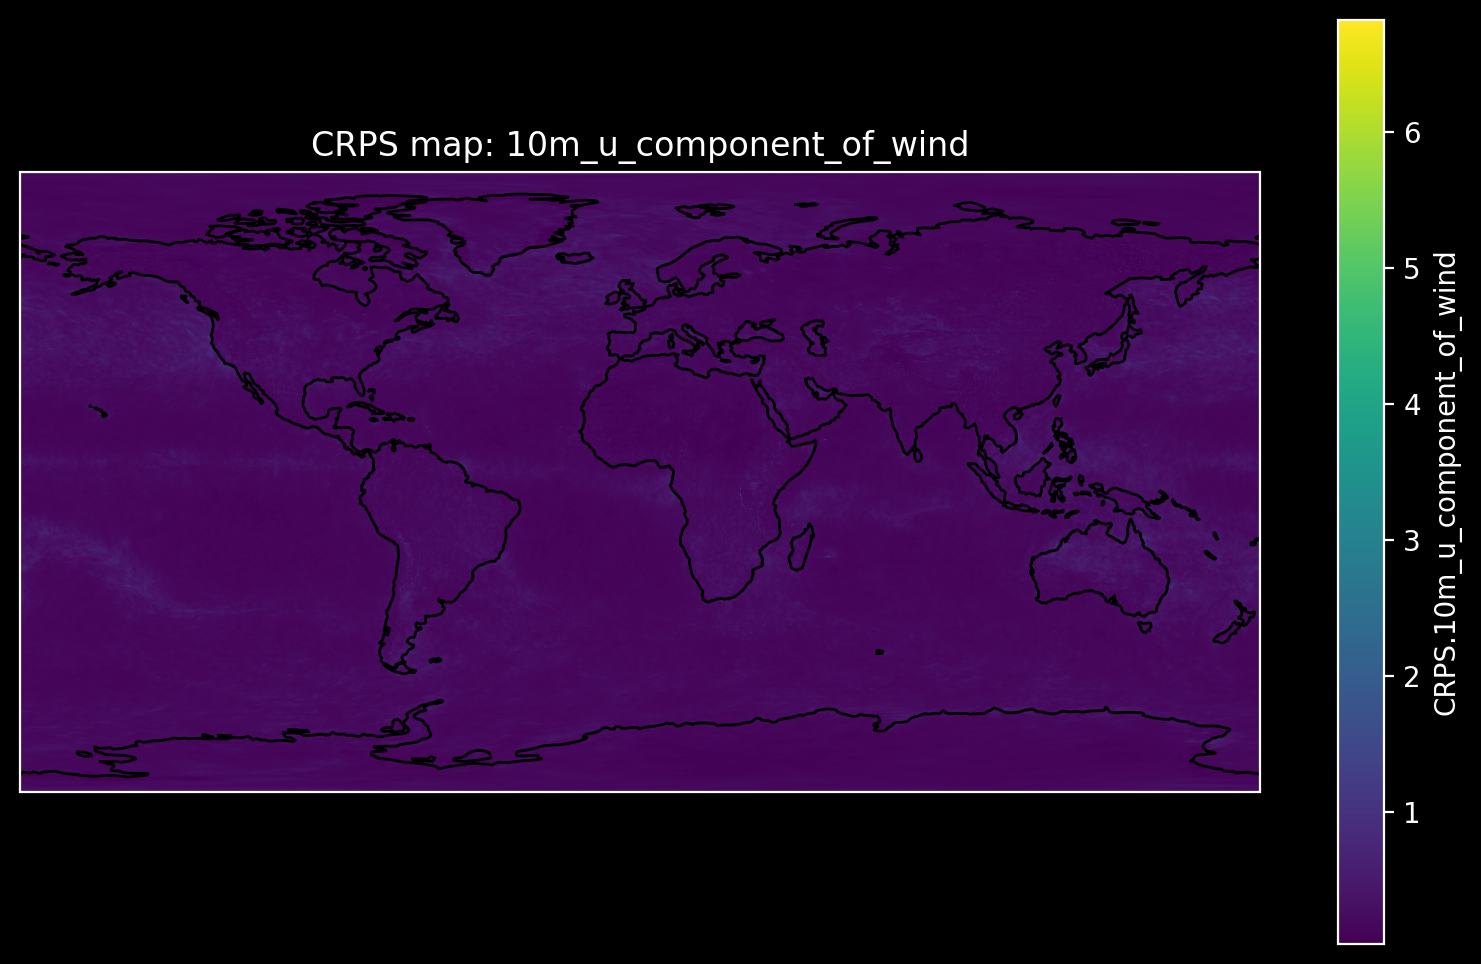

In [39]:
# Display a CRPS map PNG if present (robust discovery)
module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]

png_candidates = []
for md in module_dirs:
    if md.exists():
        png_candidates.extend(md.glob("crps_map_*.png"))

if png_candidates:
    png_path = max(png_candidates, key=lambda p: p.stat().st_mtime)
    print("Found:", png_path)
    display(Image(filename=str(png_path)))
else:
    searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
    print(f"No CRPS map PNGs found under: {searched}")